# Questioning the Data

_Are there any unusual patterns or limitations in this dataset that affect how we interpret the results?_

We've explored the distributions and relationships within the data, now let's check if the data behaves realistically.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# load data into dataframe
df = pd.read_csv("../datasets/Effectiveness_Exam_To_Sleep_Quality.csv")

#### Are there statistical outliers?

To check this, I will be using boxplots. They are used as a visual tool to check for normality or to identify points that may be outliers.

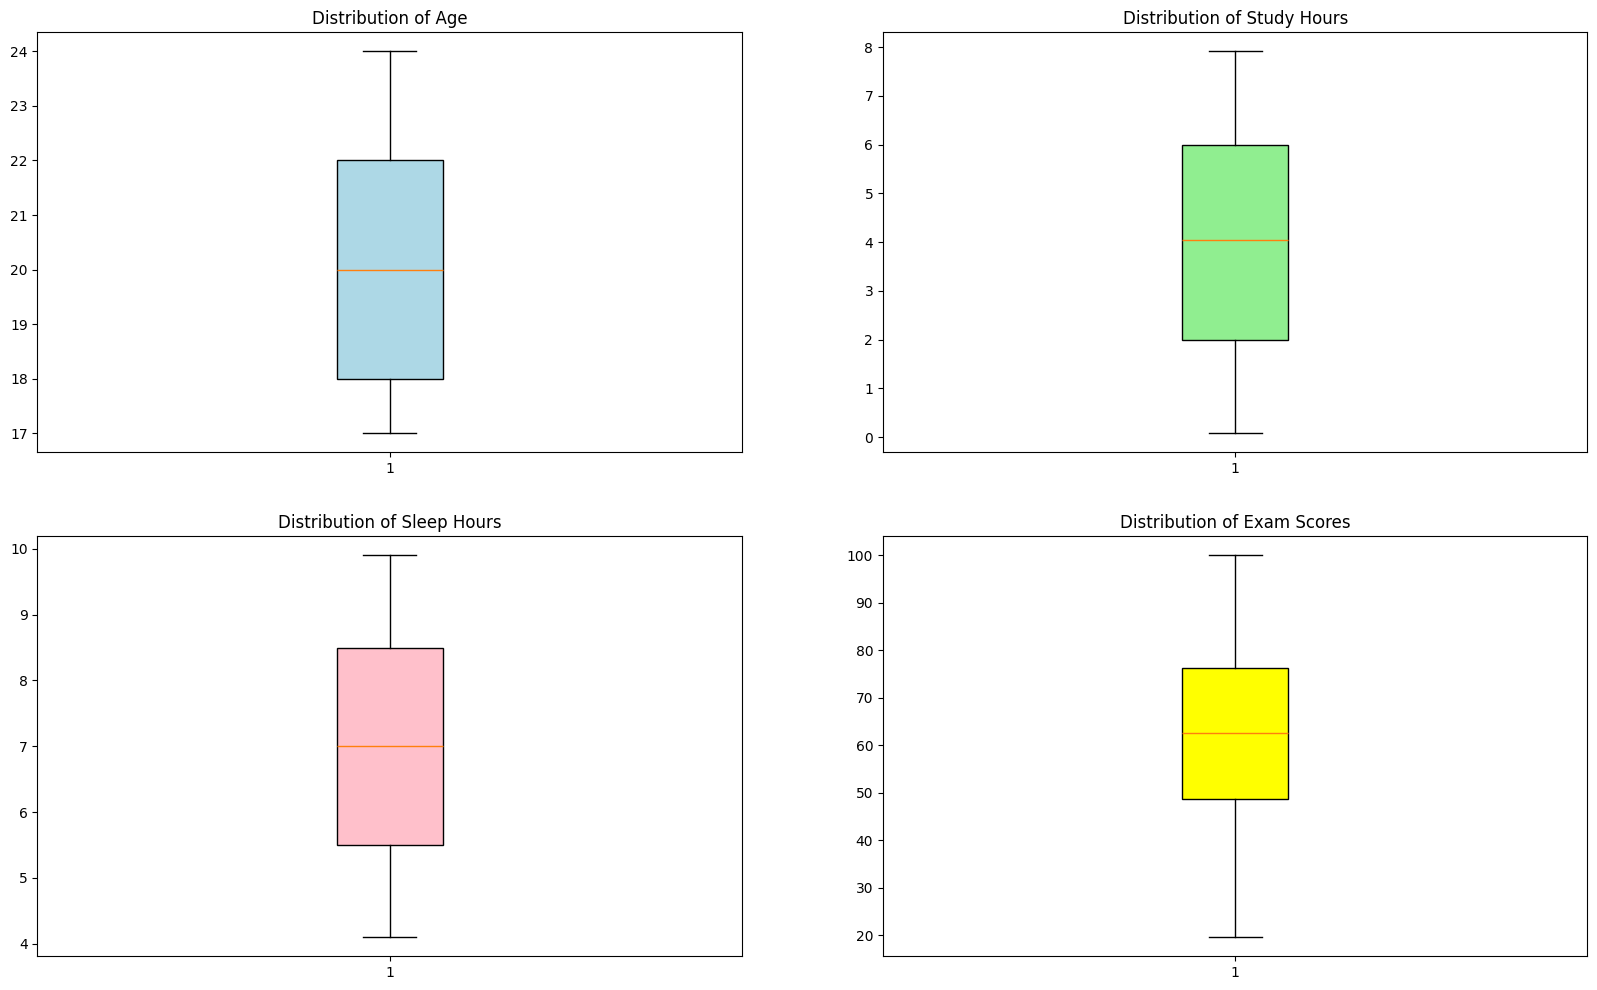

In [3]:
fig , ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

ax1.boxplot(df['age'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.boxplot(df['study_hours'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
ax3.boxplot(df['sleep_hours'], patch_artist=True, boxprops=dict(facecolor='pink'))
ax4.boxplot(df['exam_score'], patch_artist=True, boxprops=dict(facecolor='yellow'))

ax1.set_title('Distribution of Age')
ax2.set_title('Distribution of Study Hours')
ax3.set_title('Distribution of Sleep Hours')
ax4.set_title('Distribution of Exam Scores')


plt.show()

From the plots above, it appears that the dataset does not contain many extreme values. This reinforces my earlier assumption (find it in [_01_describing_data.ipynb_](01_describing_data.ipynb)), that this dataset is likely synthetic.

#### Ceiling Effect

Let's take a look at the previously plotted scatter plot of **Exams Scores by Study Hours**.

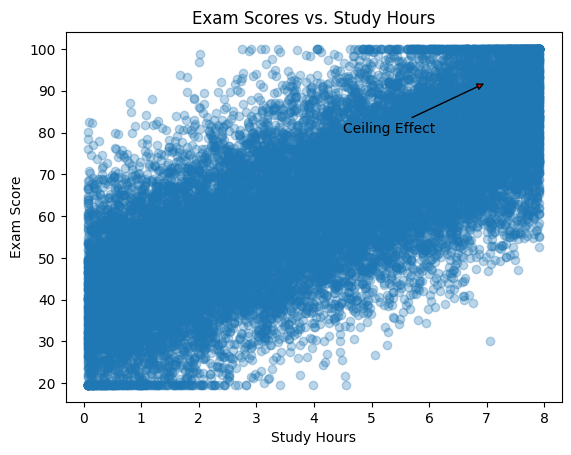

In [4]:
plt.scatter(x=df['study_hours'], y=df['exam_score'], alpha=0.3)
plt.annotate('Ceiling Effect', xy=(7, 92), xytext =(4.5, 80), 
            arrowprops = dict(facecolor ='red', arrowstyle='-|>', ), fontsize=10)

# add labels
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Exam Scores vs. Study Hours')

plt.show()

This plot indicates that there is a ceiling effect, where scores are concentrated near the maximum value (100).

**What does a ceiling effect even mean??**

A ceiling effect occurs when a large number of observations reach or approach the highest possible score. In this case, a large number of candidates' scores are clustered near the best possible score (100), or the “ceiling”, making it hard to distinguish between top performing students.

#### Relationship Anomalies

Let's take a closer look at the relationship between study hours and exam scores.

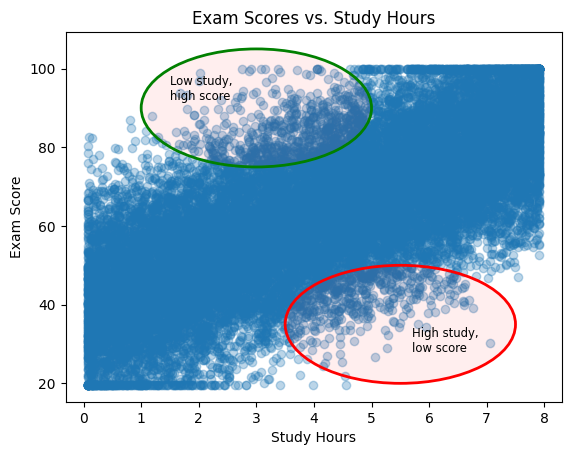

In [5]:
# plt.figure(figsize=(9, 6))
plt.scatter(x=df['study_hours'], y=df['exam_score'], alpha=0.3)
ax = plt.gca()

# highlight anomalies
low_study_high_score = patches.Ellipse((3, 90), width=4, height=30, 
                    facecolor='#FF000011', edgecolor='green', lw=2)
high_study_low_score = patches.Ellipse((5.5, 35), width=4, height=30, 
                    facecolor='#FF000011', edgecolor='red', lw=2)
# add highlights to axes
ax.add_patch(low_study_high_score)
ax.add_patch(high_study_low_score)
# add text for groups
plt.text(x=1.5, y=92, s="Low study, \nhigh score", size='small')
plt.text(x=5.7, y=28, s="High study, \nlow score", size='small')
# add labels
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Exam Scores vs. Study Hours')


plt.show()


It appears we have two groups of anomalies in this plot. 

There's Group one who spent less time studying and got a higher exam score, and Group two who spent more time studying but got a low exam score.

**Why could this possibly be?**

Could it be because students in Group one spent less time studying, but had high quality sleep? Or because they had more effective study methods? 

Could it be that students in Group two spent more time study but had poor sleep quality that affects retention?

One thing is that these observations suggest that study hours alone may not fully explain exam performance.

Let's take a closer look at the students who have a high exam score but low study hours.

In [6]:
group_one = df[(df['exam_score'] >= 80) & (df['study_hours'] < 3)]

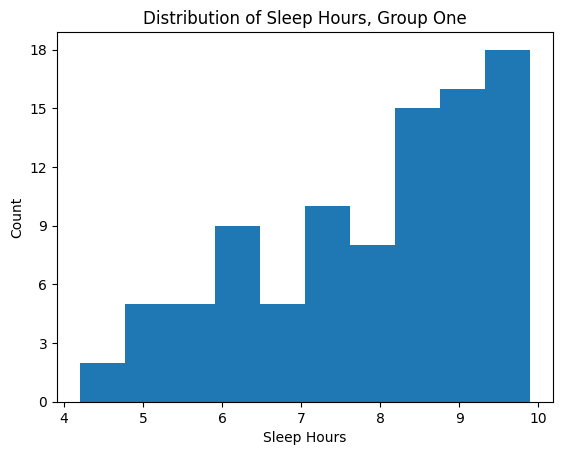

In [7]:
plt.hist(group_one['sleep_hours'])

plt.title('Distribution of Sleep Hours, Group One')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')
plt.yticks(np.arange(0, 19, 3))

plt.show()

The distribution is skewed, meaning that most of the students spend more time sleeping. 

Interesting! Let's see the quality of sleep they get.

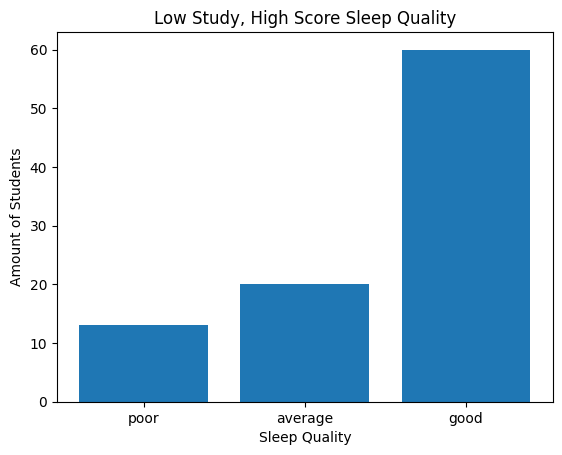

In [8]:
sleep_quality = group_one['sleep_quality'].value_counts().sort_values()
plt.bar(sleep_quality.index, sleep_quality.values)

plt.title('Low Study, High Score Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Amount of Students')

plt.show()

Students in Group one sleep longer and also get high quality sleep. This suggests that sleep hours and sleep quality may play an important role in high performance.

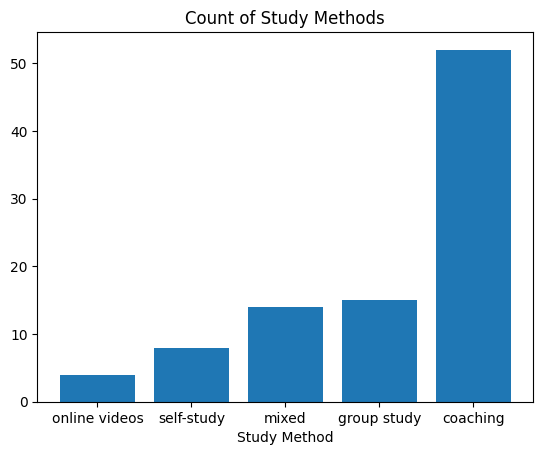

In [11]:
study_methods = group_one['study_method'].value_counts().sort_values()
plt.bar(study_methods.index, study_methods.values)
plt.xlabel('Study Method')
plt.title('Count of Study Methods')
plt.show()

Group one mostly uses coaching as their study method. This may be because it allows them to study more effectively in less time.

Students in this group tend to sleep longer, have higher sleep quality, and rely more on coaching. This suggests that the effectiveness of studying, along with high quality sleep, may be more important than the total number of hours spent studying. 

However, these observations are based on patterns within the dataset and do not imply causation.